In [34]:
import random
import torch
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from protenix.utils.lmdb import LMDBDataset
from protenix.utils.plottool import init_plot_settings
import torch.nn.functional as F

import wandb
import matplotlib.pyplot as plt

api = wandb.Api()
entity = api.default_entity

init_plot_settings()

Text(0.5, 1.0, 'screen with rerank')

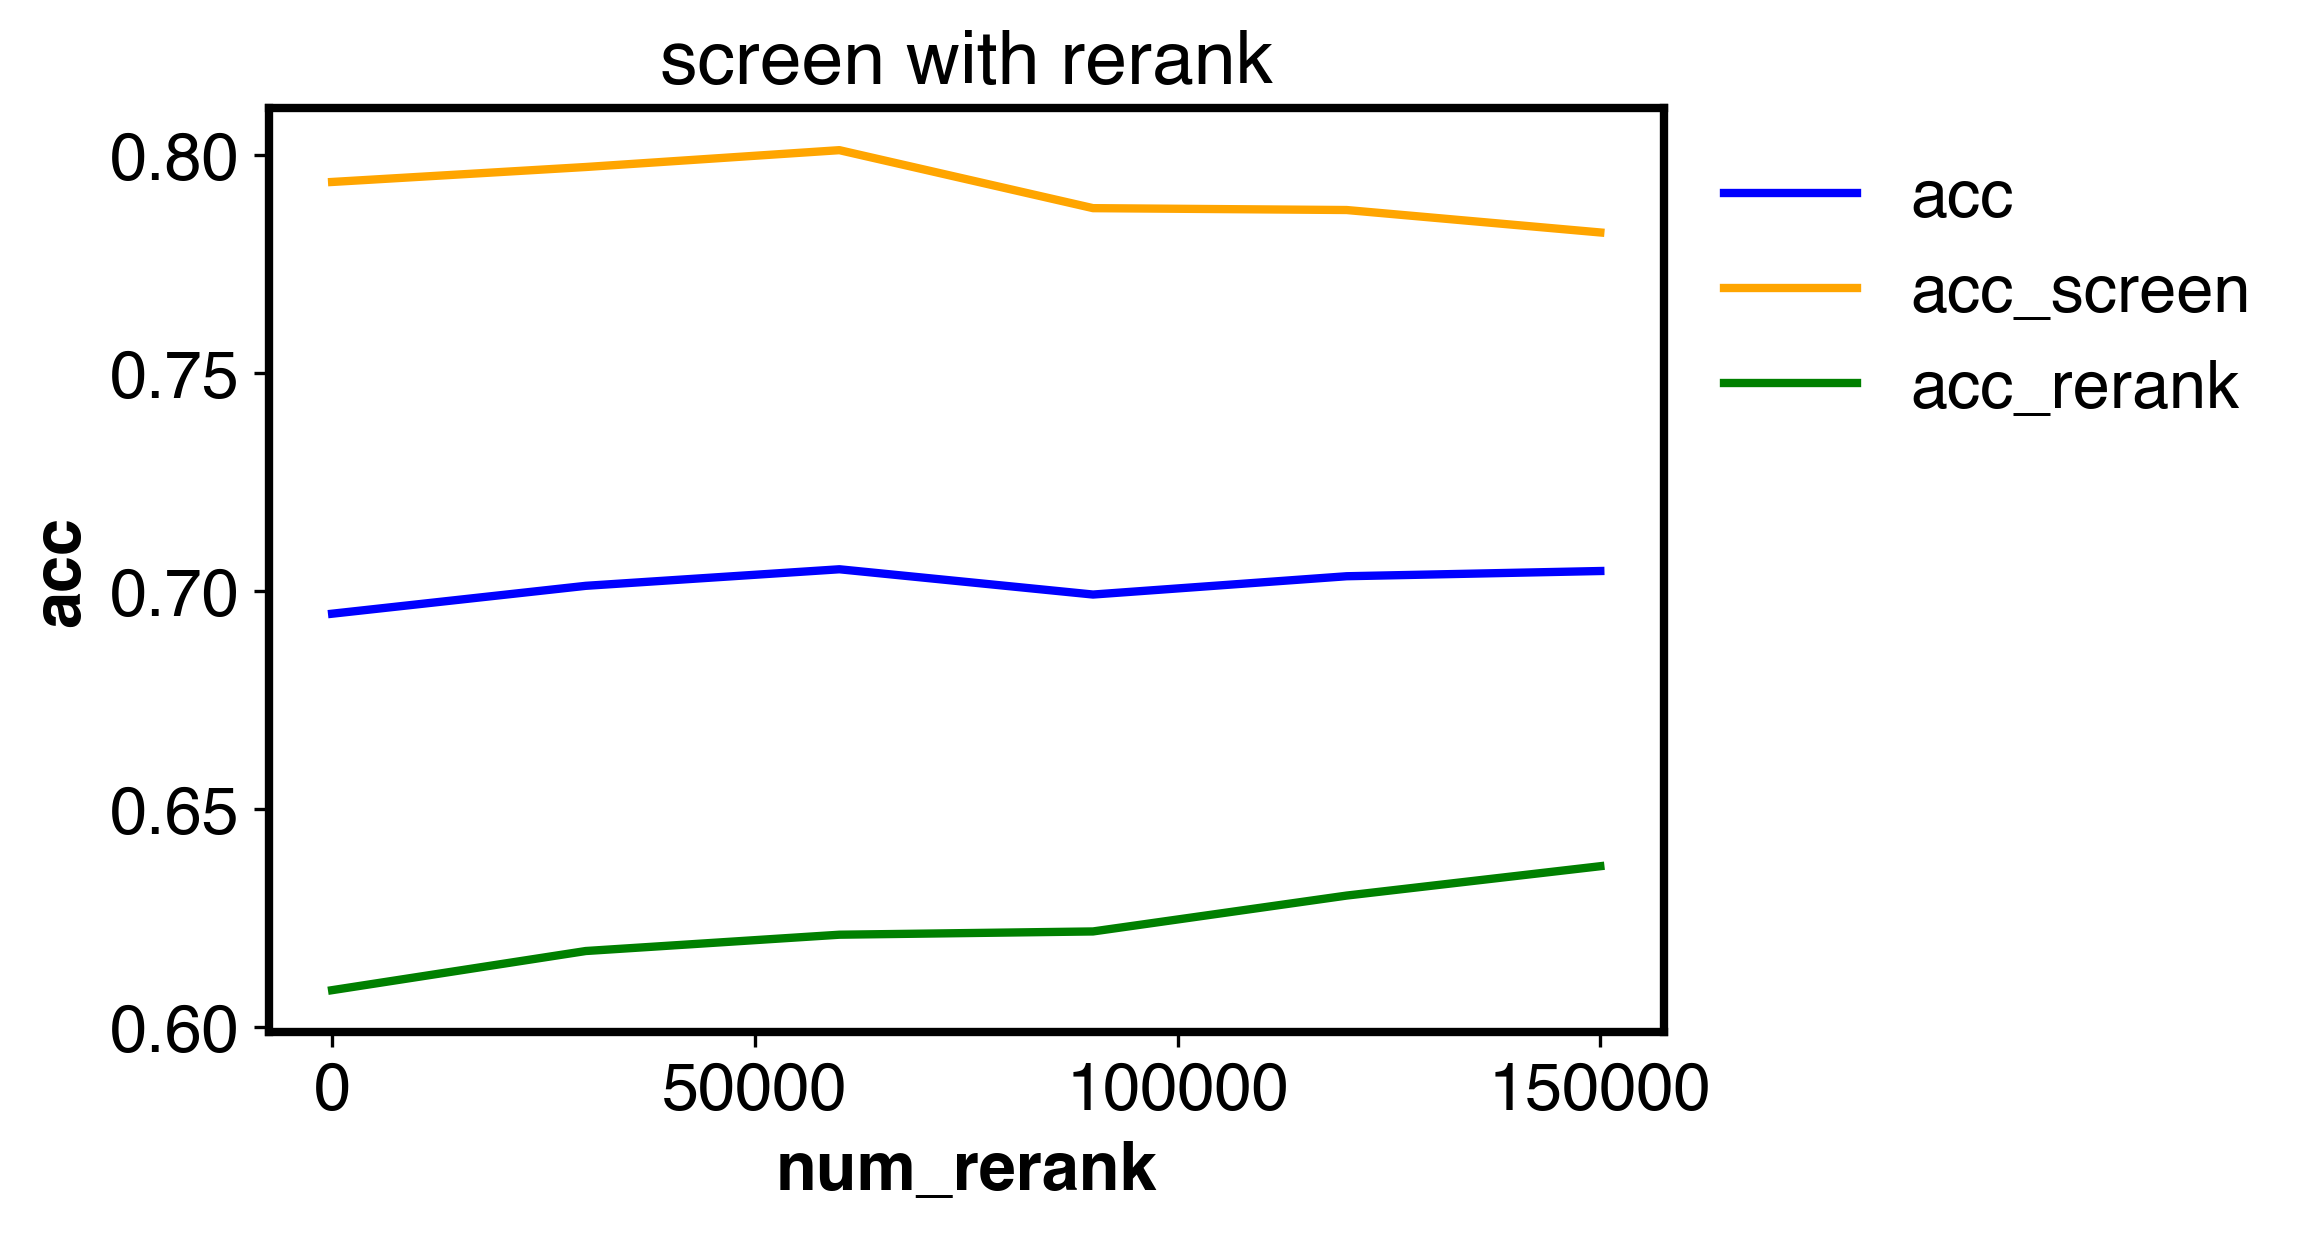

In [53]:
filters = {"tags": {"$in": ["screen_w_rank"]}}
runs = api.runs(f"{entity}/protenix", filters=filters)

screen_with_rerank = []
for run in runs:
    config = eval(run.config["dataset"])
    max_rerank = config["dataset_args"]["train"]["max_rerank"]
    if max_rerank is None:
        max_rerank = 0
    screen_with_rerank.append(
        {
            "num_rerank": max_rerank,
            "acc": run.summary["val/acc"],
            "acc_screen": run.summary["val/acc_screen"],
            "acc_rerank": run.summary["val/acc_rerank"],
        }
    )

# plot three lines, x-axis is num_rerank, y-axis is acc, acc_screen, acc_rerank
screen_with_rerank = pd.DataFrame(screen_with_rerank)
screen_with_rerank = screen_with_rerank.sort_values(by="num_rerank")
plt.figure(figsize=(6, 4))
plt.plot(
    screen_with_rerank["num_rerank"],
    screen_with_rerank["acc"],
    label="acc",
    color="blue",
)
plt.plot(
    screen_with_rerank["num_rerank"],
    screen_with_rerank["acc_screen"],
    label="acc_screen",
    color="orange",
)
plt.plot(
    screen_with_rerank["num_rerank"],
    screen_with_rerank["acc_rerank"],
    label="acc_rerank",
    color="green",
)
plt.xlabel("num_rerank")
plt.ylabel("acc")
plt.legend()
# put the legend outside the plot
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.title("screen with rerank")

Text(0.5, 1.0, 'rerank with screen')

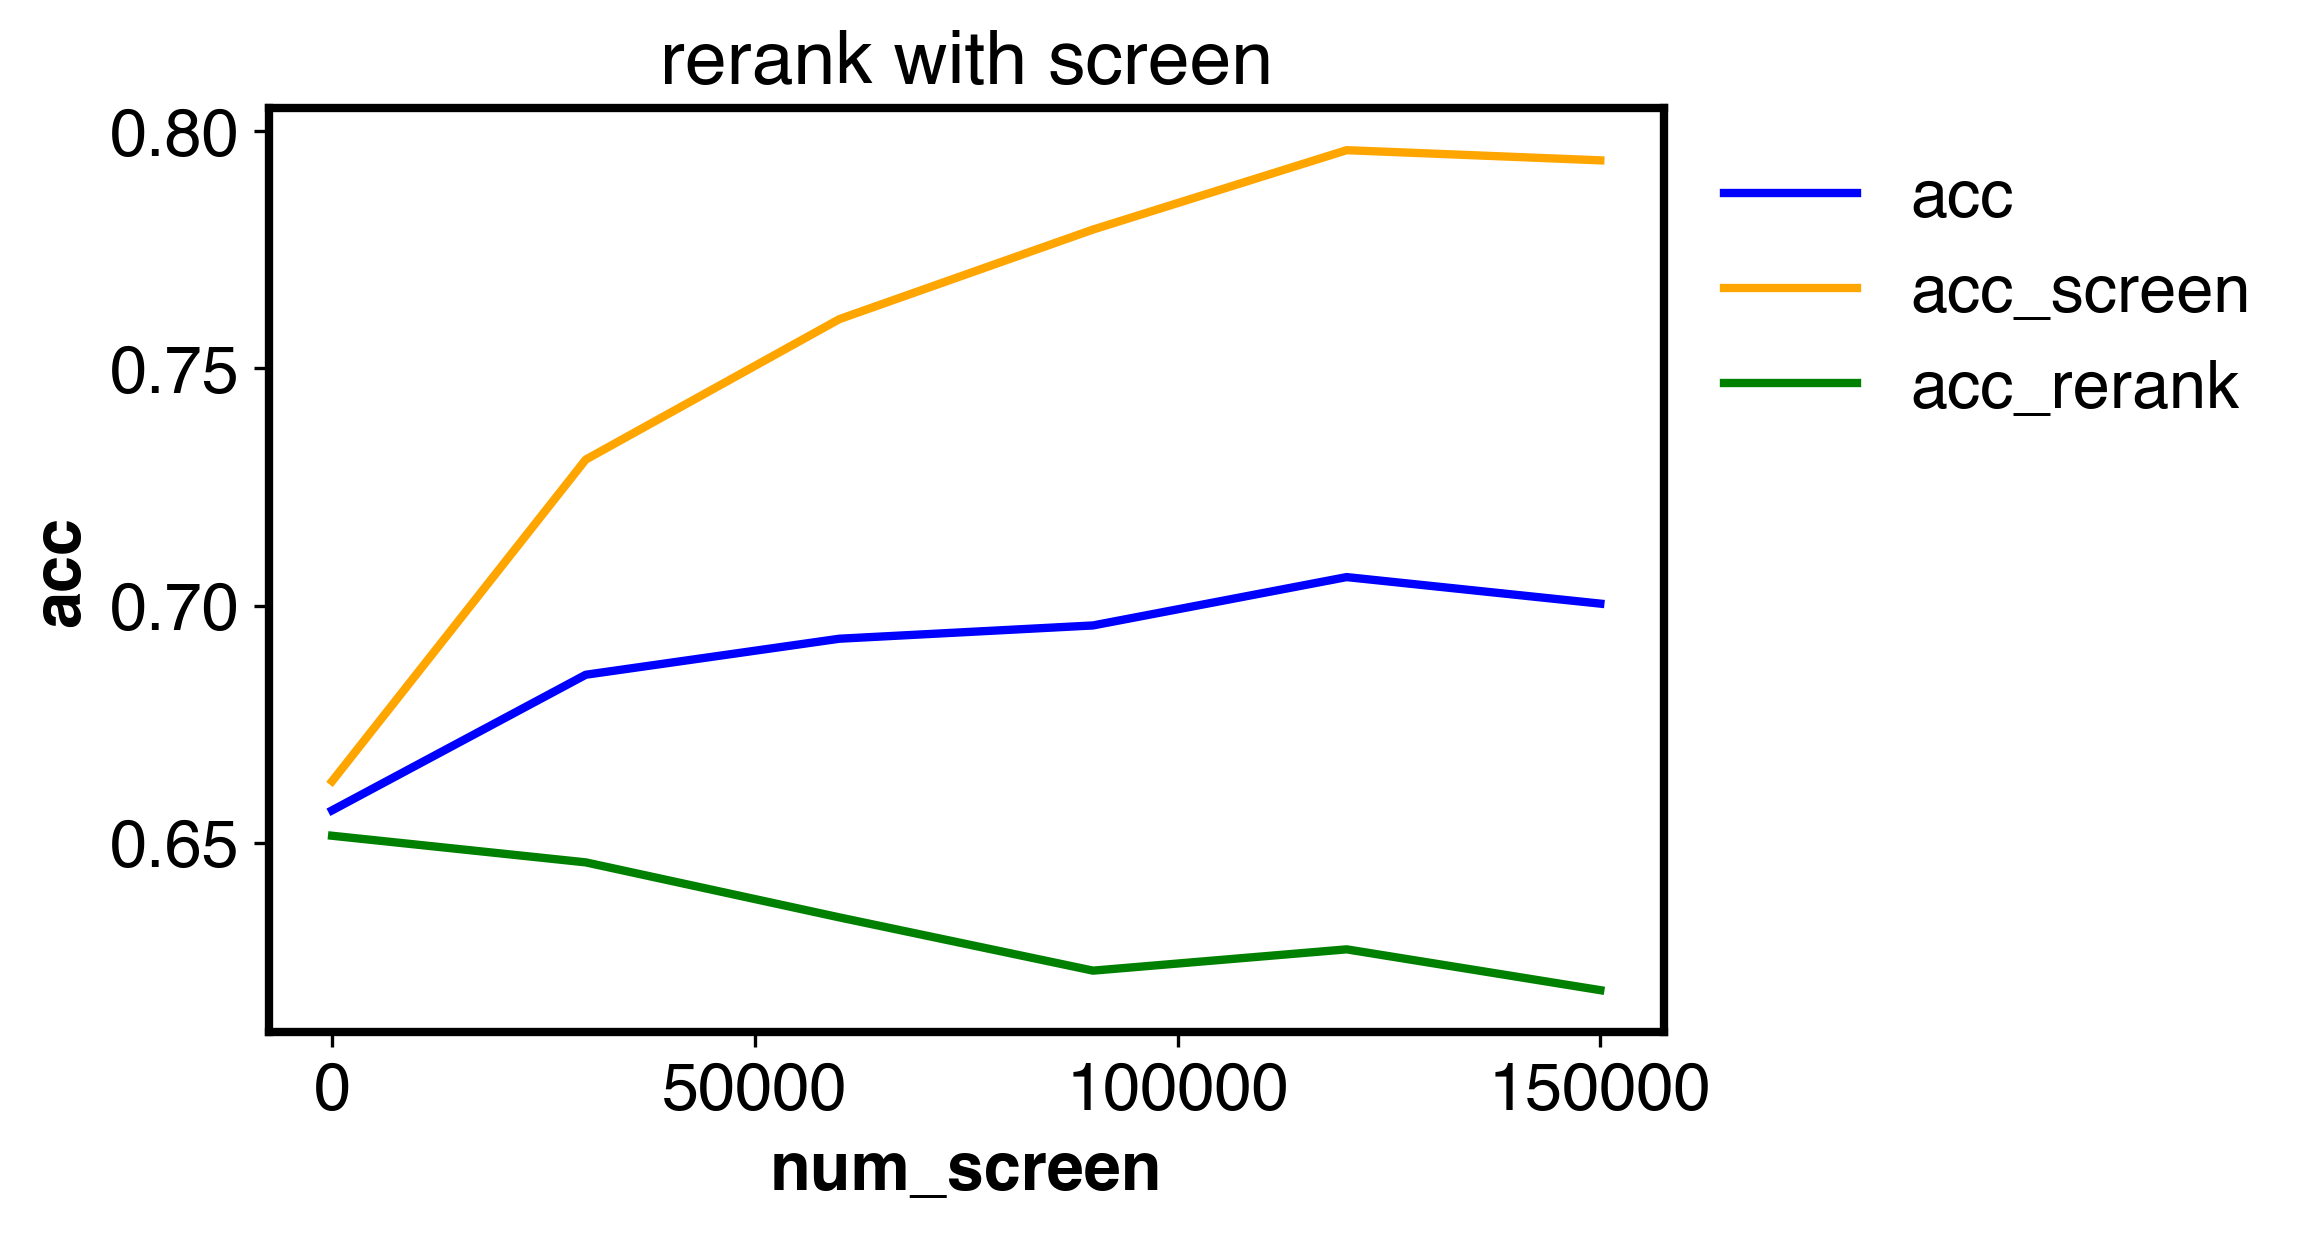

In [55]:
filters = {"tags": {"$in": ["rerank_w_screen"]}}
runs = api.runs(f"{entity}/protenix", filters=filters)
rerank_with_screen = []
for run in runs:
    config = eval(run.config["dataset"])
    max_screen = config["dataset_args"]["train"]["max_screen"]
    if max_screen is None:
        max_screen = 0
    rerank_with_screen.append(
        {
            "num_screen": max_screen,
            "acc": run.summary["val/acc"],
            "acc_screen": run.summary["val/acc_screen"],
            "acc_rerank": run.summary["val/acc_rerank"],
        }
    )

# plot three lines, x-axis is num_rerank, y-axis is acc, acc_screen, acc_rerank
rerank_with_screen = pd.DataFrame(rerank_with_screen)
rerank_with_screen = rerank_with_screen.sort_values(by="num_screen")
plt.figure(figsize=(6, 4))
plt.plot(
    rerank_with_screen["num_screen"],
    rerank_with_screen["acc"],
    label="acc",
    color="blue",
)
plt.plot(
    rerank_with_screen["num_screen"],
    rerank_with_screen["acc_screen"],
    label="acc_screen",
    color="orange",
)
plt.plot(
    rerank_with_screen["num_screen"],
    rerank_with_screen["acc_rerank"],
    label="acc_rerank",
    color="green",
)
plt.xlabel("num_screen")
plt.ylabel("acc")
plt.legend()
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.title("rerank with screen")


Text(0.5, 1.0, 'screen with rerank')

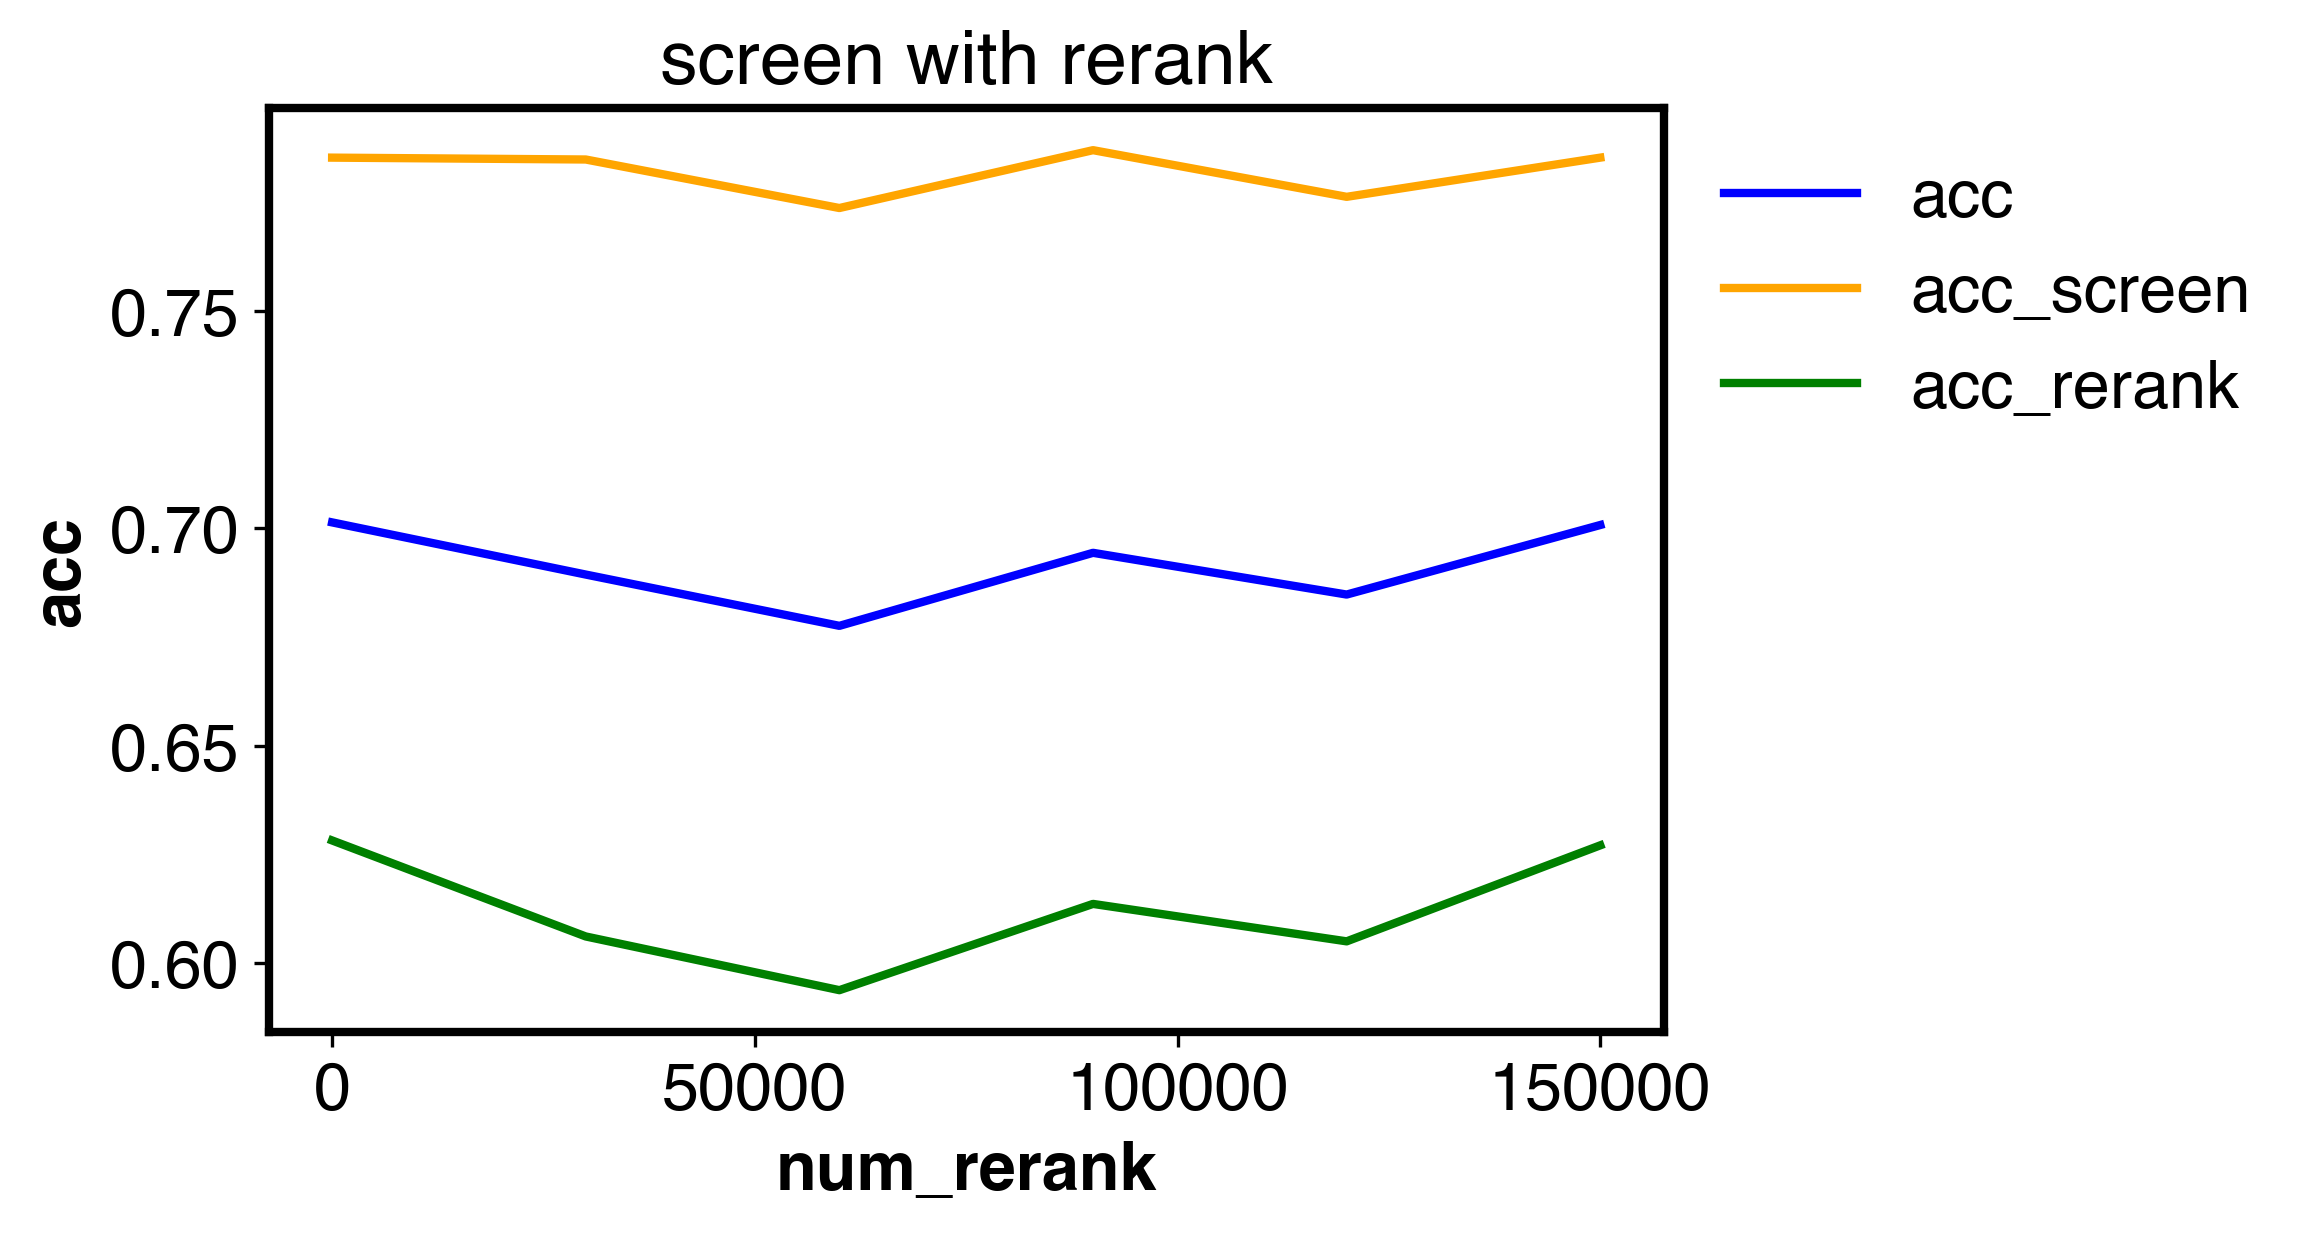

In [9]:
filters = {"tags": {"$in": ["triplet_screen_w_rerank"]}}
runs = api.runs(f"{entity}/protenix", filters=filters)

screen_with_rerank = []
for run in runs:
    config = eval(run.config["dataset"])
    max_rerank = config["dataset_args"]["train"]["max_rerank"]
    if max_rerank is None:
        max_rerank = 0
    screen_with_rerank.append(
        {
            "num_rerank": max_rerank,
            "acc": run.summary["val/acc"],
            "acc_screen": run.summary["val/acc_screen"],
            "acc_rerank": run.summary["val/acc_rerank"],
        }
    )

# plot three lines, x-axis is num_rerank, y-axis is acc, acc_screen, acc_rerank
screen_with_rerank = pd.DataFrame(screen_with_rerank)
screen_with_rerank = screen_with_rerank.sort_values(by="num_rerank")
plt.figure(figsize=(6, 4))
plt.plot(
    screen_with_rerank["num_rerank"],
    screen_with_rerank["acc"],
    label="acc",
    color="blue",
)
plt.plot(
    screen_with_rerank["num_rerank"],
    screen_with_rerank["acc_screen"],
    label="acc_screen",
    color="orange",
)
plt.plot(
    screen_with_rerank["num_rerank"],
    screen_with_rerank["acc_rerank"],
    label="acc_rerank",
    color="green",
)
plt.xlabel("num_rerank")
plt.ylabel("acc")
plt.legend()
# put the legend outside the plot
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.title("screen with rerank")

Text(0.5, 1.0, 'rerank with screen')

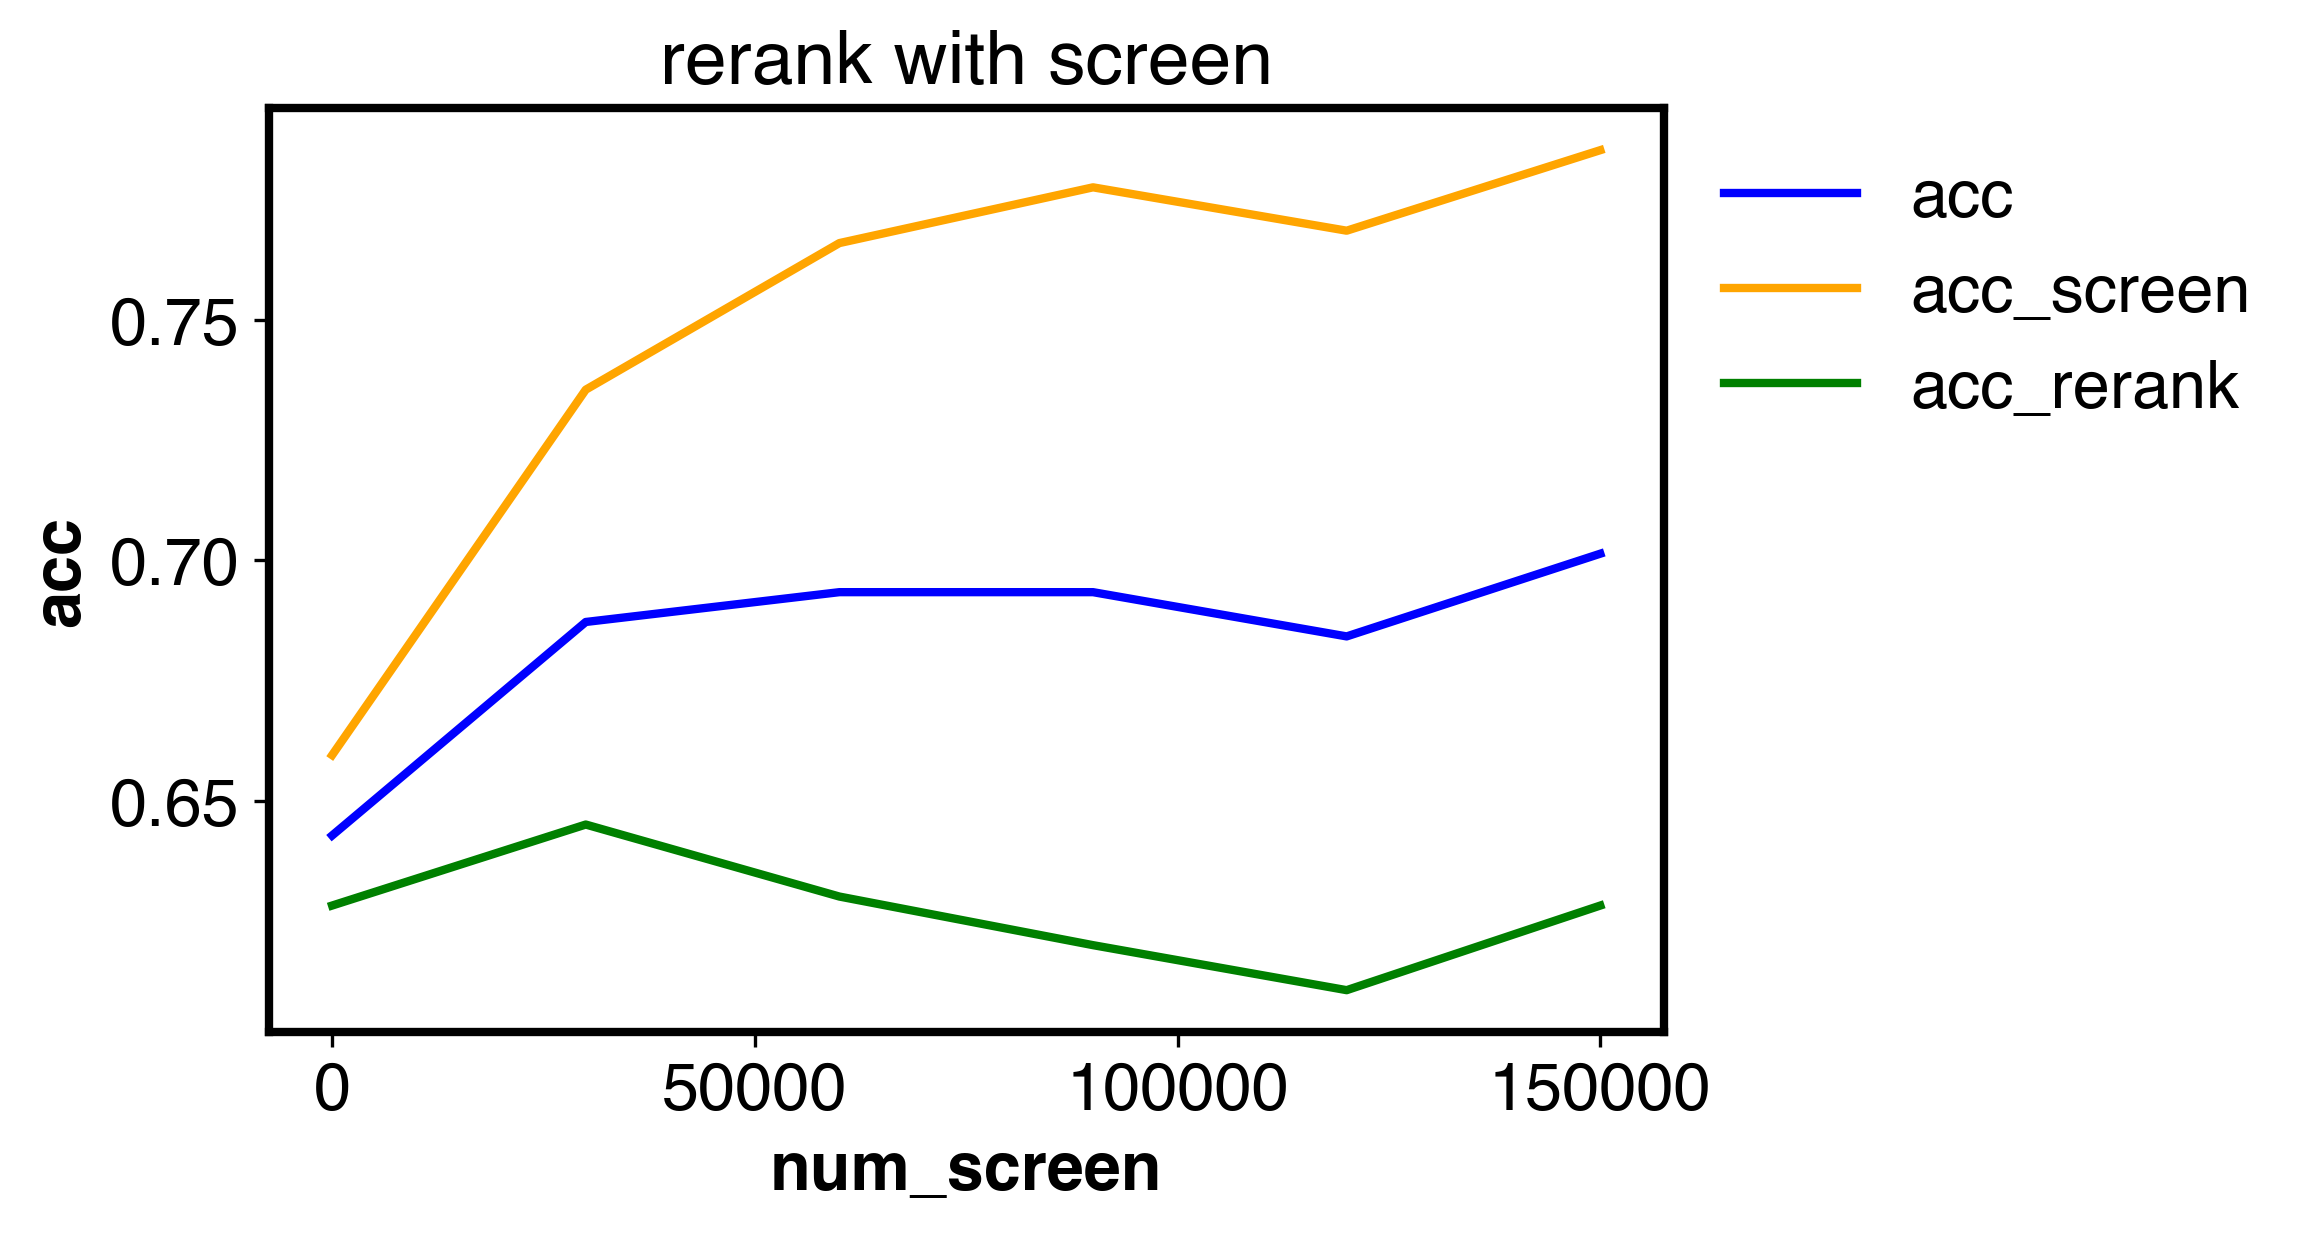

In [4]:
filters = {"tags": {"$in": ["triplet_rerank_w_screen"]}}
runs = api.runs(f"{entity}/protenix", filters=filters)
rerank_with_screen = []
for run in runs:
    config = eval(run.config["dataset"])
    max_screen = config["dataset_args"]["train"]["max_screen"]
    if max_screen is None:
        max_screen = 0
    rerank_with_screen.append(
        {
            "num_screen": max_screen,
            "acc": run.summary["val/acc"],
            "acc_screen": run.summary["val/acc_screen"],
            "acc_rerank": run.summary["val/acc_rerank"],
        }
    )

# plot three lines, x-axis is num_rerank, y-axis is acc, acc_screen, acc_rerank
rerank_with_screen = pd.DataFrame(rerank_with_screen)
rerank_with_screen = rerank_with_screen.sort_values(by="num_screen")
plt.figure(figsize=(6, 4))
plt.plot(
    rerank_with_screen["num_screen"],
    rerank_with_screen["acc"],
    label="acc",
    color="blue",
)
plt.plot(
    rerank_with_screen["num_screen"],
    rerank_with_screen["acc_screen"],
    label="acc_screen",
    color="orange",
)
plt.plot(
    rerank_with_screen["num_screen"],
    rerank_with_screen["acc_rerank"],
    label="acc_rerank",
    color="green",
)
plt.xlabel("num_screen")
plt.ylabel("acc")
plt.legend()
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.title("rerank with screen")


In [10]:
dataset = LMDBDataset(
    "/data/rerank/protenix/chembl_bdb/sample_3w/pair/sample_3w_pair_1.lmdb"
)

In [ ]:
dataset.set_default_split("full_pair")

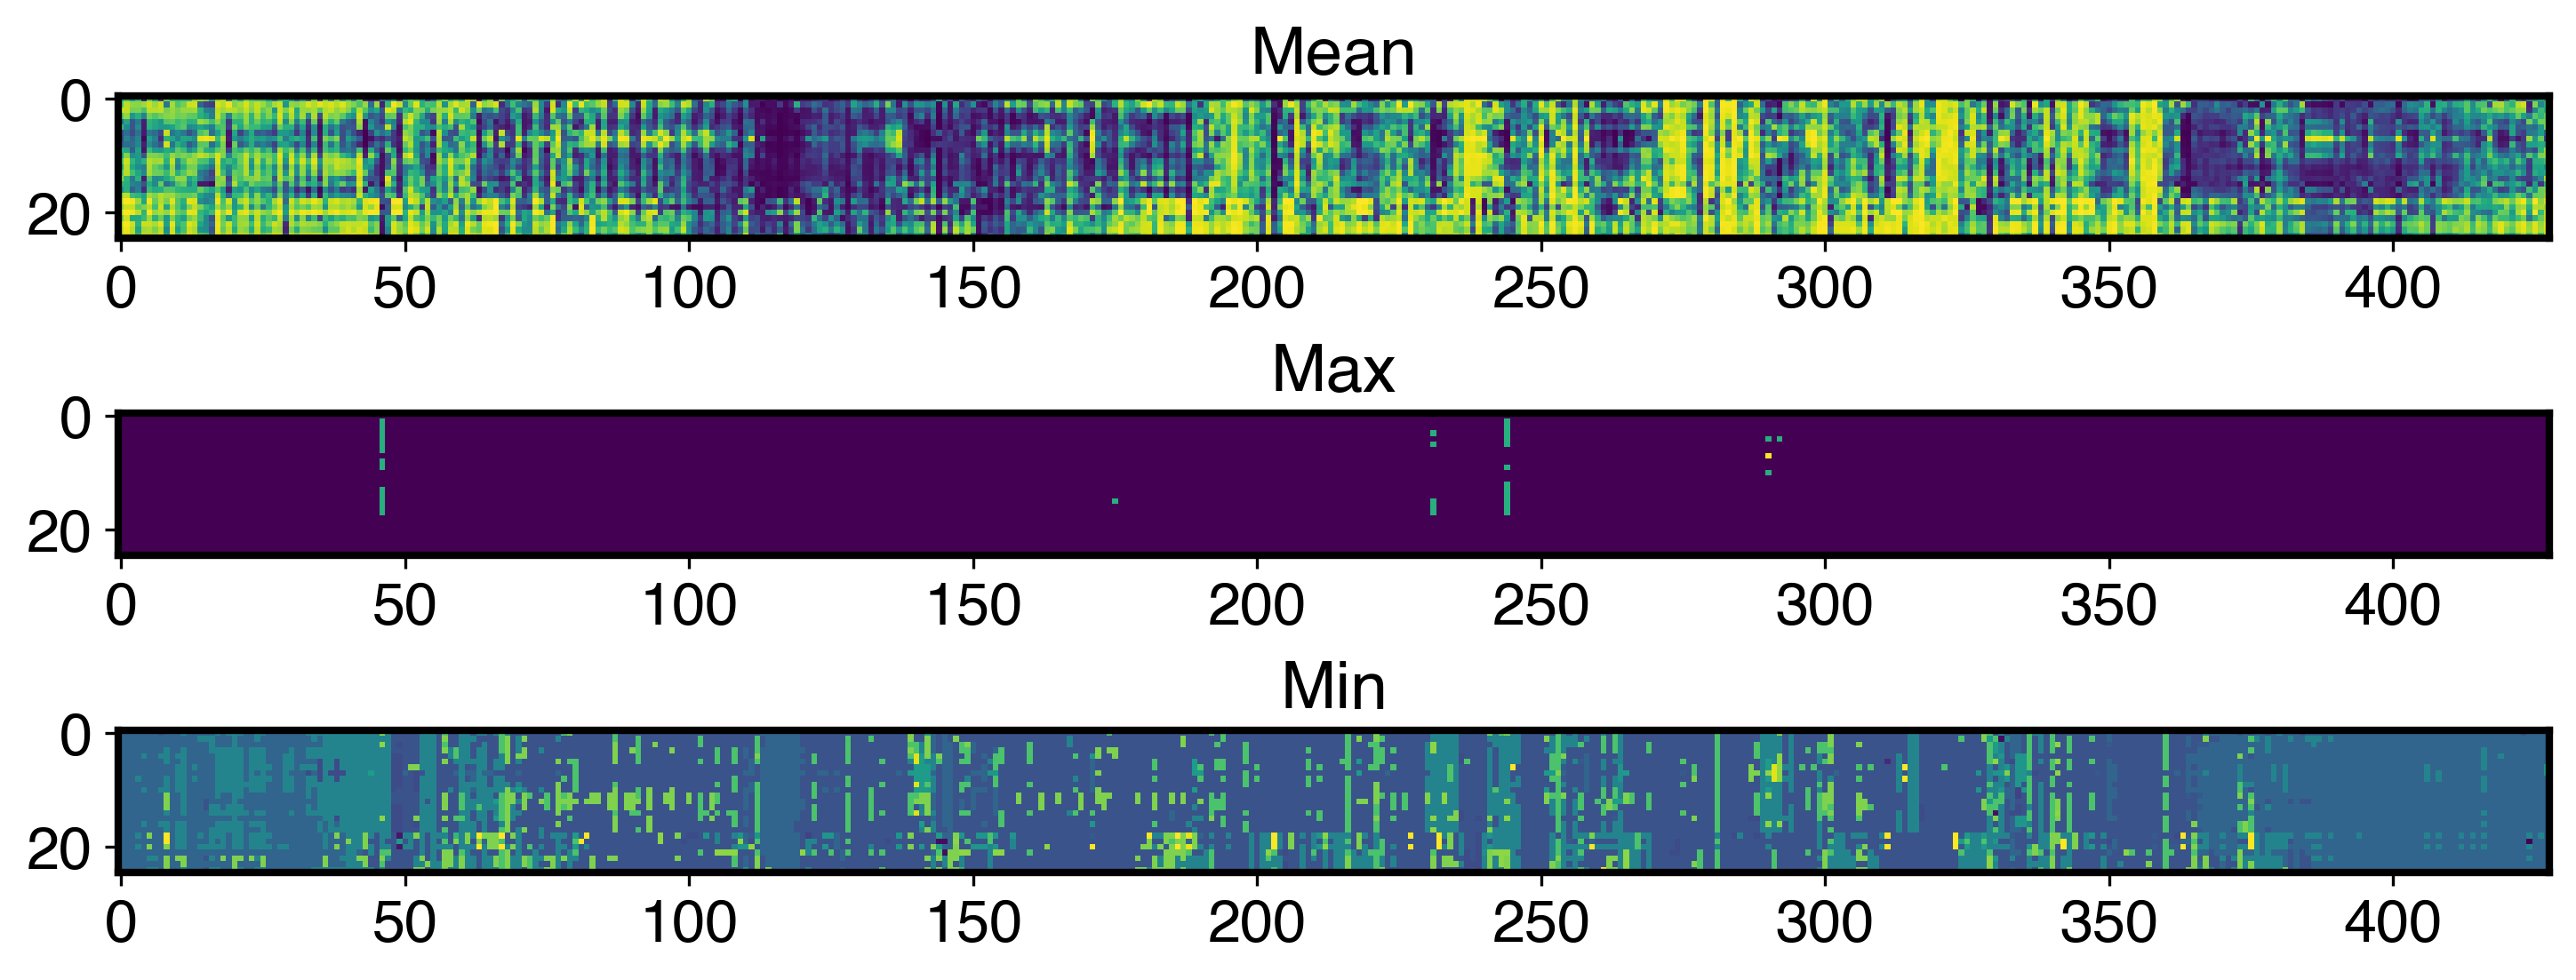

In [50]:
s_inputs, s, (z_pm, _) = random.choice(dataset)
fig, axes = plt.subplots(3, 1, figsize=(10, 4))

axes[0].imshow(F.sigmoid(z_pm.mean(dim=-1).float()).T)
axes[0].set_title("Mean")

axes[1].imshow(z_pm.max(dim=-1)[1].float().T)
axes[1].set_title("Max")

axes[2].imshow(-z_pm.min(dim=-1)[1].float().T)
axes[2].set_title("Min")

plt.tight_layout(rect=[0, 0, 1, 0.96])